# **07장. 과대적합 문제의 해결 방법**

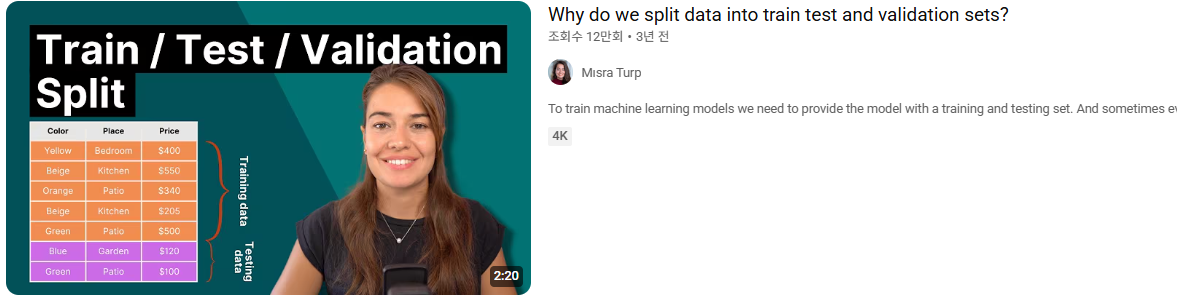

https://www.youtube.com/watch?v=dSCFk168vmo

이 동영상은 데이터를 분할하는 이유를 쉽게 설명해줍니다.  


---



In [ ]:
!pip install koreanize_matplotlib  # 패키지 인스톨 필요
import koreanize_matplotlib
import pandas as pd; import numpy as np; import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import tensorflow as tf; from tensorflow import keras
from keras.models import Model, Sequential
from keras.layers import Input, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import random
from tensorflow.keras.callbacks import Callback, EarlyStopping

[실습 07-01]

In [ ]:
df = pd.read_csv("서울아파트.csv", encoding='cp949')
df

,면적,층수,연수,구,가격
0,51.8900,16,11,서초구,8.85
1,84.9600,14,18,광진구,11.95
2,84.9600,19,9,성동구,14.45
3,59.9900,9,2,마포구,12.90
4,74.9700,4,12,서초구,12.95
...,...,...,...,...,...
9995,114.6500,6,16,성북구,8.80
9996,84.8114,8,8,금천구,10.90
9997,84.9540,1,23,동대문,6.88
9998,59.1000,6,2,성북구,8.60


[실습 07-02]

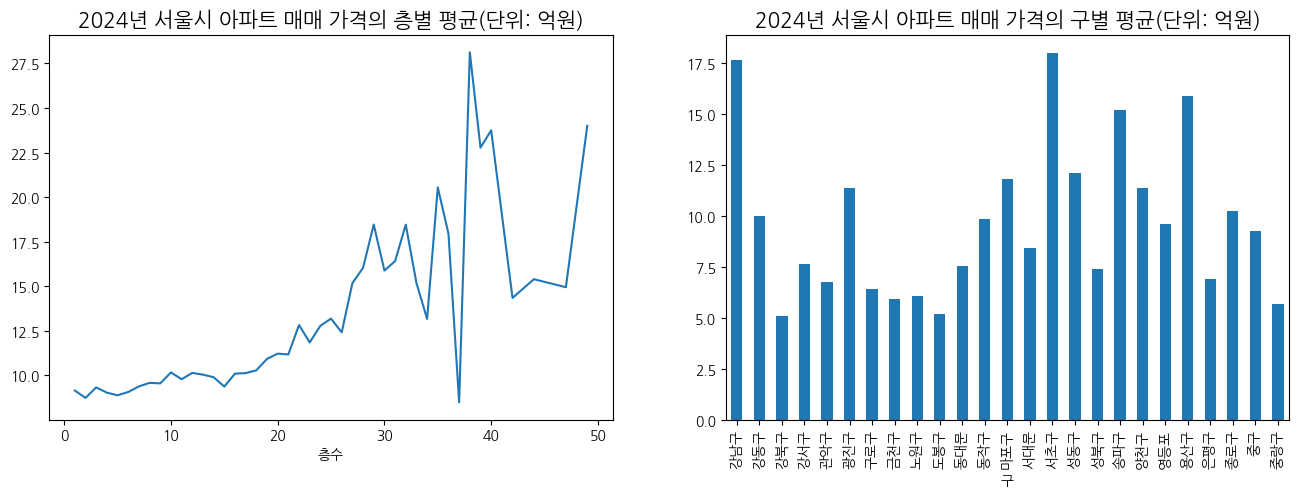

In [ ]:
plt.figure(figsize=(16, 5))
plt.subplot(1,2,1)
df.groupby('층수')['가격'].mean().plot(kind='line')
plt.title("2024년 서울시 아파트 매매 가격의 층별 평균(단위: 억원)", fontsize=15)
plt.subplot(1,2,2)
df.groupby('구')['가격'].mean().plot(kind='bar')
plt.title("2024년 서울시 아파트 매매 가격의 구별 평균(단위: 억원)", fontsize=15)
plt.show()

[실습 07-03]

In [ ]:
y=df["가격"]                 # 타깃(억원)
X=df.drop(["가격"], axis=1)  # 입력
print(X)

            면적  층수  연수    구
0      51.8900  16  11  서초구
1      84.9600  14  18  광진구
2      84.9600  19   9  성동구
3      59.9900   9   2  마포구
4      74.9700   4  12  서초구
...        ...  ..  ..  ...
9995  114.6500   6  16  성북구
9996   84.8114   8   8  금천구
9997   84.9540   1  23  동대문
9998   59.1000   6   2  성북구
9999   82.4900  11  24  동대문

[10000 rows x 4 columns]


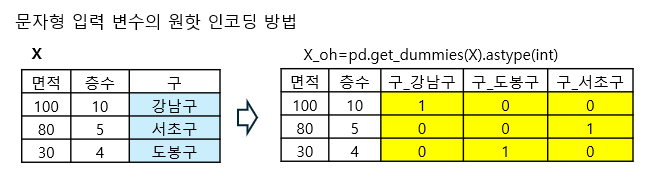

[실습 07-04]

In [ ]:
X_oh=pd.get_dummies(X).astype(int)
X_oh

,면적,층수,연수,구_강남구,구_강동구,구_강북구,구_강서구,구_관악구,구_광진구,구_구로구,...,구_성동구,구_성북구,구_송파구,구_양천구,구_영등포,구_용산구,구_은평구,구_종로구,구_중구,구_중랑구
0,51,16,11,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,84,14,18,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,84,19,9,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,59,9,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,74,4,12,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,114,6,16,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
9996,84,8,8,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,84,1,23,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9998,59,6,2,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


[실습 07-05]

In [ ]:
X_oh=np.array(X_oh)  # 배열로 변환
y=np.array(y).reshape(-1,1)
X_oh

array([[51, 16, 11, ...,  0,  0,  0],
       [84, 14, 18, ...,  0,  0,  0],
       [84, 19,  9, ...,  0,  0,  0],
       ...,
       [84,  1, 23, ...,  0,  0,  0],
       [59,  6,  2, ...,  0,  0,  0],
       [82, 11, 24, ...,  0,  0,  0]])

[실습 07-06]

In [ ]:
# 랜덤 시드 고정
SEED = 42; np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# 학습/검증 데이터 분할
x_train, x_test, y_train, y_test = train_test_split(X_oh, y, test_size=0.2, random_state=42)
print("훈련용 입력", x_train.shape); print("검증용 입력", x_test.shape)
print("훈련용 타겟", y_train.shape); print("검증용 타겟", y_test.shape)

# 모델 설정
model=Sequential([
    Input(shape=x_train[0].shape),
    Dense(64, activation='relu'),
    Dense(32,  activation='relu'),
    Dense(1)     ])
model.summary()

# 컴파일
model.compile(optimizer="adam", loss="mse")

훈련용 입력 (8000, 28)
검증용 입력 (2000, 28)
훈련용 타겟 (8000, 1)
검증용 타겟 (2000, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,969 (15.50 KB)

 Trainable params: 3,969 (15.50 KB)

 Non-trainable params: 0 (0.00 B)

[실습 07-07]

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# 조기 종료 콜백 설정
early_stop = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True )

# 학습 시작
output=model.fit(x_train, y_train,
                 validation_data=(x_test, y_test),
                 epochs=200,
                 batch_size=64,
                 callbacks=[early_stop])


Epoch 1/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 31.6101 - val_loss: 20.6894
Epoch 2/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 19.3330 - val_loss: 19.4104
Epoch 3/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 17.7056 - val_loss: 17.1413
Epoch 4/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 14.9058 - val_loss: 13.5349
Epoch 5/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 11.7361 - val_loss: 10.6802
Epoch 6/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.7578 - val_loss: 9.2889
Epoch 7/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8.9055 - val_loss: 8.7249
Epoch 8/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.4569 - val_loss: 8.3497
Epoch 9/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.1654 - val_loss: 8.1102
Epoch 10/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.9527 - val_loss: 7.9522
Epoch 11/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.7839 - val_loss: 7.8271
Epoch 12/200
125/125 ━━━━━━━━━━

[실습 07-08]

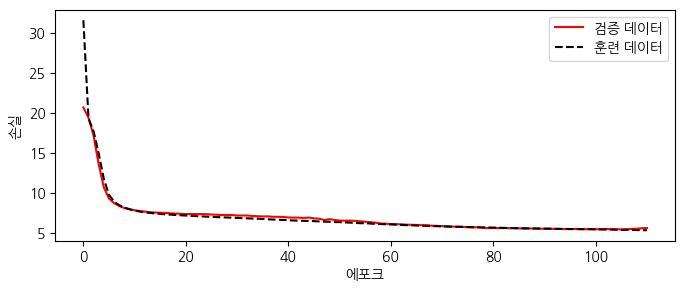

In [ ]:
plt.figure(figsize=(8, 3))

plt.plot(output.history['val_loss'], 'r-', label='검증 데이터')

plt.plot(output.history['loss'], 'k--', label='훈련 데이터')

plt.xlabel('에포크');
plt.ylabel('손실')
plt.legend()
plt.show()


[실습 07-09]

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


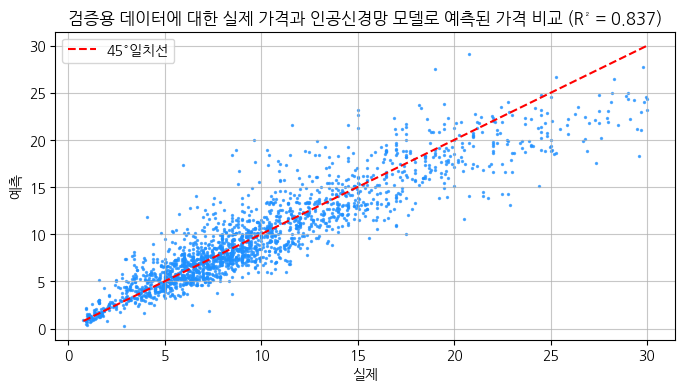

In [ ]:
# R²예측력 계산
y_pred=model.predict(x_test)
r2 = r2_score(y_test, y_pred)

# 예측값과 실제값 비교
plt.figure(figsize=(8, 4))
plt.scatter(y_test, y_pred, color='dodgerblue', alpha=0.7, s=2)  # alpha는 투명도 설정 (0~1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='45°일치선')
plt.title(f'검증용 데이터에 대한 실제 가격과 인공신경망 모델로 예측된 가격 비교 (R² = {r2:.3f})')
plt.xlabel('실제'); plt.ylabel('예측')
plt.legend(); plt.grid(alpha=0.7); plt.show()

## **입력 변수가 타깃 예측에 미치는 효과 분석**
### 아이디어:
1.   가상 입력 생성: 하나의 입력 변수만 다르게 하고 나머지 입력 변수는 특정 값으로 고정.
2.   가상 입력을 모델에 입력하여 예측값 계산
3.   그래프로 시각화






### 자치구의 효과를 살펴봅시다

(1) 25개 자치구의 고유값을 추출합니다.

In [ ]:
gu_label=np.unique(df["구"])
gu_label

array(['강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구', '노원구',
       '도봉구', '동대문', '동작구', '마포구', '서대문', '서초구', '성동구', '성북구', '송파구',
       '양천구', '영등포', '용산구', '은평구', '종로구', '중구', '중랑구'], dtype=object)

(2) 모델의 입력 변수(X) 순서를 확인해 봅시다.
모델과 동일한 형태의 가상 입력 데이터를 만들어야 합니다.

In [ ]:
X.columns

Index(['면적', '층수', '연수', '구'], dtype='object')

(3) '구'만 다르고 나머지 입력 변수는 특정한 값으로 고정된 가상 데이터프레임을 만듭니다.
* [실습 04-15]와 유사한 방법입니다.

In [ ]:
X_plot=pd.DataFrame({
    '면적': 75,          # 고정
    '층수': 10,          # 고정
    '연수': 10,          # 고정
    '구': gu_label       # 구 이름 리스트(변동)
    })
X_plot

,면적,층수,연수,구
0,75,10,10,강남구
1,75,10,10,강동구
2,75,10,10,강북구
3,75,10,10,강서구
4,75,10,10,관악구
5,75,10,10,광진구
6,75,10,10,구로구
7,75,10,10,금천구
8,75,10,10,노원구
9,75,10,10,도봉구


(4) 모델의 입력(X_oh)과 같이 원핫 인코딩합니다.

In [ ]:
X_input=pd.get_dummies(X_plot).astype(int)
X_input

,면적,층수,연수,구_강남구,구_강동구,구_강북구,구_강서구,구_관악구,구_광진구,구_구로구,...,구_성동구,구_성북구,구_송파구,구_양천구,구_영등포,구_용산구,구_은평구,구_종로구,구_중구,구_중랑구
0,75,10,10,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,75,10,10,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,75,10,10,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,75,10,10,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,75,10,10,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,75,10,10,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
6,75,10,10,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7,75,10,10,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,75,10,10,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,75,10,10,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


(5) 원핫 인코딩된 가상 입력을 학습된 모델에 입력하여, 예측값을 구하고 그래프로 그립니다.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step


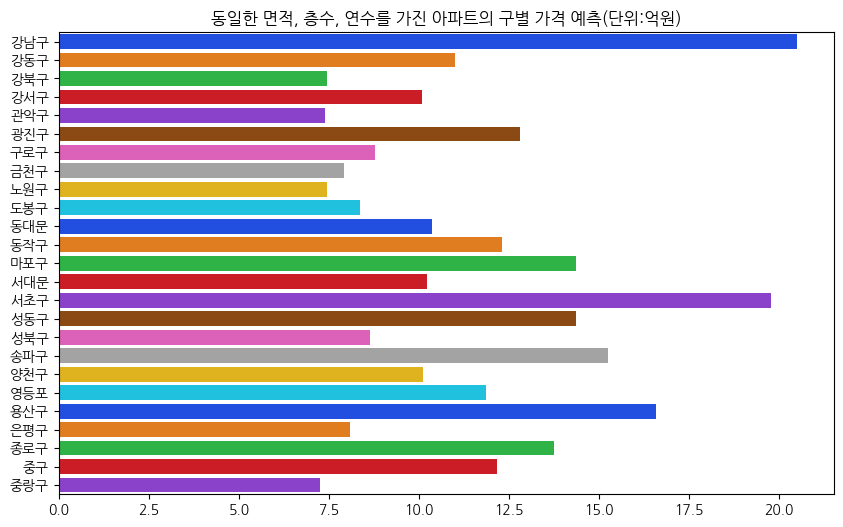

In [ ]:
gu_pred=model.predict(X_input).reshape(-1)  # 예측 후 1차원으로 변환
plt.figure(figsize=(10, 6))
sns.barplot(x=gu_pred, y=gu_label, hue=gu_label, palette='bright')
plt.title("동일한 면적, 층수, 연수를 가진 아파트의 구별 가격 예측(단위:억원)")
plt.show()

* 결과를 보면 강남구>서초구>용산구 순으로 나타나는데, 이것은 [실습 07-02]에 살펴본 평균 매매 가격이 아니라
* 동일한 스펙의 아파트가 오로지 아파트의 위치에 따라 달라지는 가격 차이이므로 **입지 프리미엄**(location premium)이라 할 수 있습니다.
* 유사한 방법으로 다른 입력 변수의 효과도 시각화할 수 있습니다.